# Lab 4.06 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 6 - Influence of background music on purchasing behaviour

Market research shows that background music in a supermarket can influence the purchasing behaviour of customers. A study compared three methods: no music, French chansons and Italian hits. In each case, the number of bottles of French, Italian and other wines sold was counted (Ryan, et al., 1998).

The research data can be found in the file data/MuziekWijn.csv.

1. Set up the correct crosstab.
2. Determine the marginal totals.
3. Determine the expected results.
4. Calculate the χ² test statistic.
5. Calculate Cramér's V. What can you conclude from this?

Visualize the data set:

1. Plot a bar chart showing the percentages of types of wine sold when no music was playing.
2. Plot a clustered bar chart of the dataset
3. Plot a bar chart (stacked bar chart) of the dataset

Results of the main calculations (rounded up to 3 decimal places):

* χ² ≈ 18.279
* Cramér's V ≈ 0.194

In [3]:
muziek_wijn = pd.read_csv('https://raw.githubusercontent.com/warre-van-lancker/dsai-labs/refs/heads/main/data/MuziekWijn.csv')
muziek_wijn.head()

,Muziek,Wijn
0,Geen,Franse
1,Franse,Franse
2,Franse,Italiaanse
3,Italiaanse,Andere
4,Italiaanse,Franse


Read the dataset

Give the names of both columns. What is wrong?

In [5]:
muziek_wijn.columns

Index(['Muziek', ' Wijn'], dtype='str')

You can change the name of a column 'ab' to the column 'abc' of the dataframe df, using the following command

`df = df.rename(columns={'ab': 'abc'})`

Use this command to change the column name.  
Check afterwards if the result is correct.

In [6]:
muziek_wijn = muziek_wijn.rename(columns={' Wijn': 'Wijn'})
muziek_wijn.columns

Index(['Muziek', 'Wijn'], dtype='str')

1. Set up the correct crosstab.

In [11]:
observed = pd.crosstab(muziek_wijn['Wijn'], muziek_wijn['Muziek'])
observed

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,35,43,35
Franse,39,30,30
Italiaanse,1,11,19


2. Determine the marginal totals.

In [12]:
row_sums = observed.sum(axis=1)
col_sums = observed.sum()
n = row_sums.sum()

3. Determine the expected results.

In [14]:
expected = np.outer(row_sums, col_sums) / n
expected

array([[34.87654321, 39.0617284 , 39.0617284 ],
       [30.55555556, 34.22222222, 34.22222222],
       [ 9.56790123, 10.71604938, 10.71604938]])

4. Calculate the χ² test statistic.

In [15]:
diffs = (expected - observed)**2 / expected
chi_squared = diffs.values.sum()
print(f"χ²                ≈ {chi_squared:.3f}")

χ²                ≈ 18.279


5. Calculate Cramér's V. What can you conclude from this?

In [17]:
cramers_v = np.sqrt(chi_squared / ((min(observed.shape) - 1) * n))
cramers_v

np.float64(0.19393696480652944)

Plot a bar chart showing the percentages of types of wine sold when no music was playing.

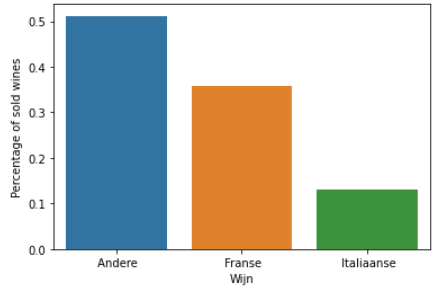

<Axes: xlabel='Wijn', ylabel='Percentages'>

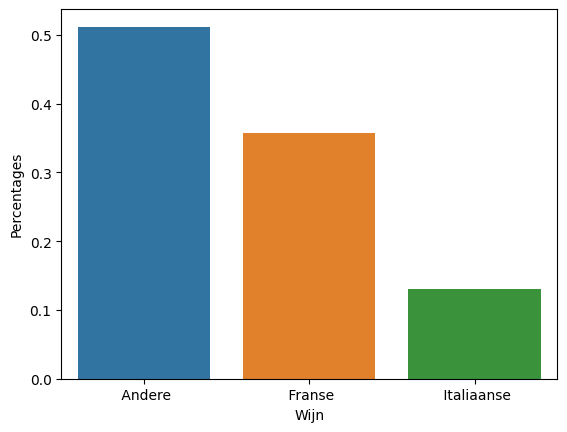

In [33]:
df_help = muziek_wijn[muziek_wijn['Muziek']=='Geen'].groupby('Wijn').count().reset_index()
n = sum(df_help['Muziek'])
df_help['Percentages'] = df_help['Muziek'] / n
sns.barplot(data=df_help, x='Wijn', y='Percentages', hue='Wijn')

Plot a clustered bar chart of the dataset  

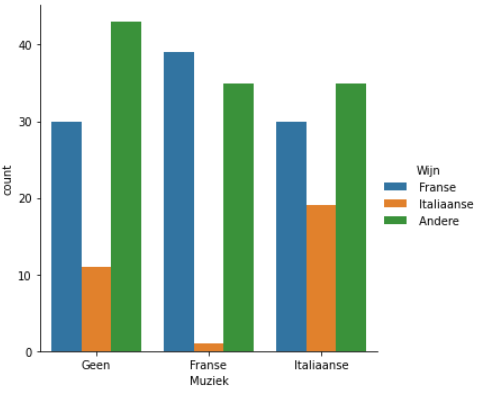

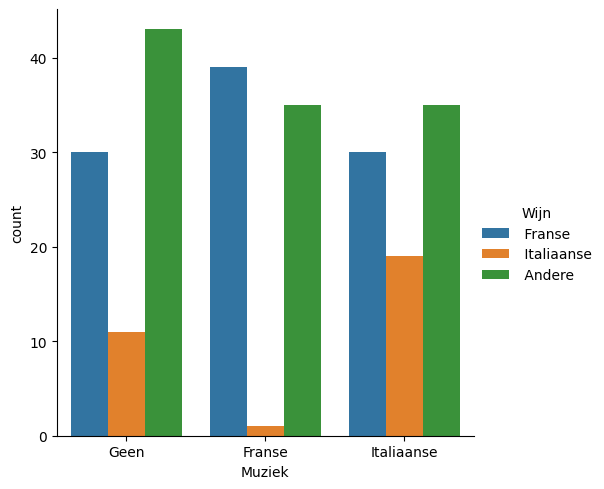

In [39]:
sns.catplot(data=muziek_wijn, x='Muziek', hue='Wijn', kind='count')

Plot a bar chart (stacked bar chart) of the dataset

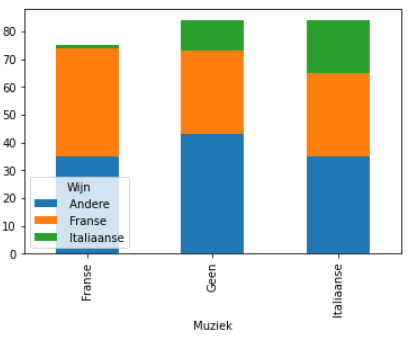

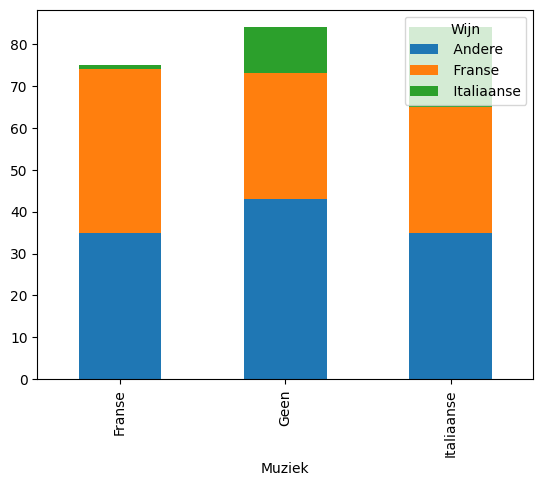

In [43]:
observed.T.plot(kind='bar', stacked=True);